In [ ]:
from google.colab import drive
drive.mount('/content/drive')
## refill misssing neumarical values with median and those things

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# PART 0: SETUP

In [27]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# TensorFlow
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.metrics import Precision, Recall

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                            classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

# Create directories
for d in ['models', 'figures', 'outputs']:
    os.makedirs(d, exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Random seed set to: {RANDOM_SEED}")

TensorFlow version: 2.20.0
Random seed set to: 42


# PART A - STEP 1: LOAD AND INSPECT

In [28]:
MISSING_MARKERS = ['NA', 'N/A', 'na', 'n/a', 'null', 'NULL', 'None', 'none',
                   '-', '--', 'missing', 'Missing', 'unknown', 'Unknown',
                   ' ', '', 'NULL']

# Load data
df = pd.read_csv('/content/drive/MyDrive/BrainTumorClassification/brain_tumor_data.csv', na_values=MISSING_MARKERS)

print(f"\nDataset shape: {df.shape}")
print(f"Expected: (9000, 29) - 1 ID + 27 features + 1 target\n")

print("Column data types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
print(df.head())

# Identify column types based on data dictionary
ID_COL = 'patient_id'
TARGET_COL = 'tumor_type'

NUMERIC_COLS = [
    'age', 'bmi', 'tumor_size_mm', 'tumor_growth_rate', 'headache_severity',
    'mri_intensity', 'ct_density', 'edema_grade', 'ki67_index',
    'bp_systolic', 'bp_diastolic', 'wbc_count', 'crp_level'
]

CATEGORICAL_COLS = [
    'gender', 'ethnicity', 'region', 'smoking_status', 'family_history',
    'tumor_location', 'nausea', 'vision_problems', 'seizures',
    'memory_loss', 'balance_issues', 'genetic_marker_status'
]

ORDINAL_COLS = ['alcohol_consumption', 'contrast_enhancement']

print(f"\nIdentifier column: {ID_COL}")
print(f"Target column: {TARGET_COL}")
print(f"Numeric columns ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"Categorical columns ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")
print(f"Ordinal columns ({len(ORDINAL_COLS)}): {ORDINAL_COLS}")



Dataset shape: (9000, 29)
Expected: (9000, 29) - 1 ID + 27 features + 1 target

Column data types:
patient_id                object
age                        int64
gender                    object
ethnicity                 object
region                    object
bmi                      float64
smoking_status            object
alcohol_consumption       object
family_history            object
tumor_size_mm            float64
tumor_location            object
tumor_growth_rate        float64
headache_severity        float64
nausea                    object
vision_problems           object
seizures                  object
memory_loss               object
balance_issues            object
mri_intensity            float64
ct_density               float64
edema_grade              float64
contrast_enhancement      object
ki67_index               float64
bp_systolic                int64
bp_diastolic             float64
wbc_count                float64
crp_level                float64
genetic_m

# PART A - STEP 2: MISSING VALUES

In [29]:
# Check for numeric columns that loaded as object (text) due to string markers
print("\nChecking for numeric columns loaded as text:")
object_cols = df.select_dtypes(include=['object']).columns.tolist()
object_cols.remove(ID_COL)  # Keep ID as object
object_cols.remove(TARGET_COL)  # Keep target as object
print(f"Object columns (excluding ID and target): {object_cols}")

# Check which supposed-numeric columns are in object type
numeric_as_object = [c for c in NUMERIC_COLS if c in df.select_dtypes(include=['object']).columns]
print(f"Numeric columns that loaded as object: {numeric_as_object}")

# Force conversion to numeric (coerce errors to NaN)
for col in NUMERIC_COLS:
    if df[col].dtype == 'object':
        print(f"  Converting {col} from {df[col].dtype} to numeric")
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean gender lowercase issue (per data dictionary)
print(f"\nGender value counts before cleaning:")
print(df['gender'].value_counts())
df['gender'] = df['gender'].str.strip().str.capitalize()
print(f"Gender value counts after cleaning:")
print(df['gender'].value_counts())

# Missing value counts per column
missing_counts = df.isnull().sum()
print(f"\nMissing values per column:")
print(missing_counts[missing_counts > 0].sort_values(ascending=False))



Checking for numeric columns loaded as text:
Object columns (excluding ID and target): ['gender', 'ethnicity', 'region', 'smoking_status', 'alcohol_consumption', 'family_history', 'tumor_location', 'nausea', 'vision_problems', 'seizures', 'memory_loss', 'balance_issues', 'contrast_enhancement', 'genetic_marker_status']
Numeric columns that loaded as object: []

Gender value counts before cleaning:
gender
Female    4841
Male      4066
female      56
male        37
Name: count, dtype: int64
Gender value counts after cleaning:
gender
Female    4897
Male      4103
Name: count, dtype: int64

Missing values per column:
alcohol_consumption     4185
contrast_enhancement    1136
ki67_index               664
tumor_growth_rate        540
headache_severity        457
crp_level                445
bmi                      436
ct_density               434
smoking_status           381
mri_intensity            356
family_history           356
edema_grade              283
ethnicity                281
w

# PART A - STEP 3: ENCODING AND SCALING


In [30]:
# Separate features and target
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL]

print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Encode target: Integer labels (0, 1, 2) for SparseCategoricalCrossentropy
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nTarget encoding:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} -> {i}")

# Save label encoder
joblib.dump(label_encoder, 'models/label_encoder.pkl')

# Define ordinal category orders (must match data dictionary)
ALCOHOL_ORDER = ['None', 'Moderate', 'Heavy']
CONTRAST_ORDER = ['None', 'Mild', 'Moderate', 'Strong']

print(f"\nOrdinal category orders:")
print(f"  alcohol_consumption: {ALCOHOL_ORDER}")
print(f"  contrast_enhancement: {CONTRAST_ORDER}")

# Build preprocessing pipelines
# Numeric: Impute median + StandardScaler
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Impute most_frequent + OneHotEncoder
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ordinal: Impute most_frequent + OrdinalEncoder
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[ALCOHOL_ORDER, CONTRAST_ORDER],
                              handle_unknown='use_encoded_value',
                              unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_COLS),
    ('cat', categorical_pipeline, CATEGORICAL_COLS),
    ('ord', ordinal_pipeline, ORDINAL_COLS)
], remainder='drop')  # Drop any unexpected columns


Features shape: (9000, 27)
Target distribution:
tumor_type
Glioma        3802
Meningioma    3089
Pituitary     2109
Name: count, dtype: int64

Target encoding:
  Glioma -> 0
  Meningioma -> 1
  Pituitary -> 2

Ordinal category orders:
  alcohol_consumption: ['None', 'Moderate', 'Heavy']
  contrast_enhancement: ['None', 'Mild', 'Moderate', 'Strong']


# PART A - STEP 4: CLASS DISTRIBUTION

In [31]:
class_dist = pd.Series(y).value_counts().sort_index()
class_props = class_dist / len(y)
print(f"\nClass distribution (counts):")
print(class_dist)
print(f"\nClass distribution (proportions):")
print(class_props)

is_balanced = class_props.max() < 0.5 and class_props.min() > 0.2
print(f"\nIs the dataset balanced? {'Yes' if is_balanced else 'No'}")
print(f"Max class proportion: {class_props.max():.3f}")
print(f"Min class proportion: {class_props.min():.3f}")

# Compute class weights (will apply during training)
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights: {class_weight_dict}")



Class distribution (counts):
tumor_type
Glioma        3802
Meningioma    3089
Pituitary     2109
Name: count, dtype: int64

Class distribution (proportions):
tumor_type
Glioma        0.422444
Meningioma    0.343222
Pituitary     0.234333
Name: count, dtype: float64

Is the dataset balanced? Yes
Max class proportion: 0.422
Min class proportion: 0.234

Class weights: {0: np.float64(0.7890583903208838), 1: np.float64(0.9711880867594691), 2: np.float64(1.422475106685633)}


# PART C - STEP 1: DATA SPLITTING


In [32]:
df.head()

,patient_id,age,gender,ethnicity,region,bmi,smoking_status,alcohol_consumption,family_history,tumor_size_mm,...,ct_density,edema_grade,contrast_enhancement,ki67_index,bp_systolic,bp_diastolic,wbc_count,crp_level,genetic_marker_status,tumor_type
0,PT100001,60,Male,African,Rural,28.1,Never,Moderate,No,13.0,...,51.4,0.0,Mild,0.7,103,85.0,7.56,7.81,Positive,Meningioma
1,PT100002,50,Male,Asian,Urban,25.0,Never,Moderate,No,14.5,...,35.2,0.0,NaN,NaN,134,97.0,9.17,4.37,Positive,Pituitary
2,PT100003,74,Female,Other,Suburban,21.0,Never,NaN,No,10.7,...,43.0,1.0,Strong,3.4,127,62.0,3.67,10.16,Inconclusive,Meningioma
3,PT100004,34,Male,Hispanic,Suburban,29.2,Never,NaN,No,36.7,...,18.5,3.0,Mild,5.6,100,80.0,7.55,1.70,Positive,Glioma
4,PT100005,59,Male,Asian,Rural,28.2,Former,Moderate,No,16.0,...,24.0,1.0,Moderate,1.4,132,77.0,9.35,8.14,?,Pituitary


In [33]:

# Split: 70% train, 15% validation, 15% test
# First split off test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.15, random_state=RANDOM_SEED, stratify=y_encoded
)

# Split temp into train (70%) and validation (15%)
# 0.15 / 0.85 = 0.17647
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.17647, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X):.1%})")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.1%})")

# FIT preprocessing on training data ONLY
print(f"\nFitting preprocessing pipeline on training data ONLY...")
preprocessor.fit(X_train)

# Transform all sets
X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"Processed feature shape: {X_train_proc.shape}")

# Save fitted preprocessor
joblib.dump(preprocessor, 'models/preprocessing_pipeline.pkl')

# Get feature names for later interpretation
# One-hot feature names
onehot_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = onehot_encoder.get_feature_names_out(CATEGORICAL_COLS)

# Ordinal feature names
ord_feature_names = ORDINAL_COLS

# Combine all feature names
feature_names = NUMERIC_COLS + list(cat_feature_names) + ord_feature_names
print(f"Total features after preprocessing: {len(feature_names)}")

Train set: 6300 samples (70.0%)
Validation set: 1350 samples (15.0%)
Test set: 1350 samples (15.0%)

Fitting preprocessing pipeline on training data ONLY...
Processed feature shape: (6300, 51)
Total features after preprocessing: 51


In [34]:
print('\nSaving processed data to CSV files...')

# Convert processed features to DataFrame with feature names
X_train_proc_df = pd.DataFrame(X_train_proc, columns=feature_names)
X_val_proc_df = pd.DataFrame(X_val_proc, columns=feature_names)
X_test_proc_df = pd.DataFrame(X_test_proc, columns=feature_names)

# Add target column using original target names
X_train_proc_df['target'] = label_encoder.inverse_transform(y_train)
X_val_proc_df['target'] = label_encoder.inverse_transform(y_val)
X_test_proc_df['target'] = label_encoder.inverse_transform(y_test)

# Save to CSV
X_train_proc_df.to_csv('outputs/X_train_processed_with_target.csv', index=False)
X_val_proc_df.to_csv('outputs/X_val_processed_with_target.csv', index=False)
X_test_proc_df.to_csv('outputs/X_test_processed_with_target.csv', index=False)

print('Processed training data saved as outputs/X_train_processed_with_target.csv')
print('Processed validation data saved as outputs/X_val_processed_with_target.csv')
print('Processed test data saved as outputs/X_test_processed_with_target.csv')


Saving processed data to CSV files...
Processed training data saved as outputs/X_train_processed_with_target.csv
Processed validation data saved as outputs/X_val_processed_with_target.csv
Processed test data saved as outputs/X_test_processed_with_target.csv


In [35]:
input_dim = X_train_proc.shape[1]

def build_model(input_dim, lr=0.001, dropout_rate=0.3, l2_reg=0.001):
    if not isinstance(input_dim, int) or input_dim <= 0:
        raise ValueError(f"input_dim must be positive int")

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg),
                    name='dense_1'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(32, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg),
                    name='dense_2'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(16, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg),
                    name='dense_3'),

        layers.Dense(3, activation='softmax', name='output')
    ], name='brain_tumor_classifier')

    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')] # Explicitly using SparseCategoricalAccuracy
    )

    model.summary()
    return model

model = build_model(input_dim)


Model: "brain_tumor_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,371 (24.89 KB)

 Trainable params: 6,179 (24.14 KB)

 Non-trainable params: 192 (768.00 B)

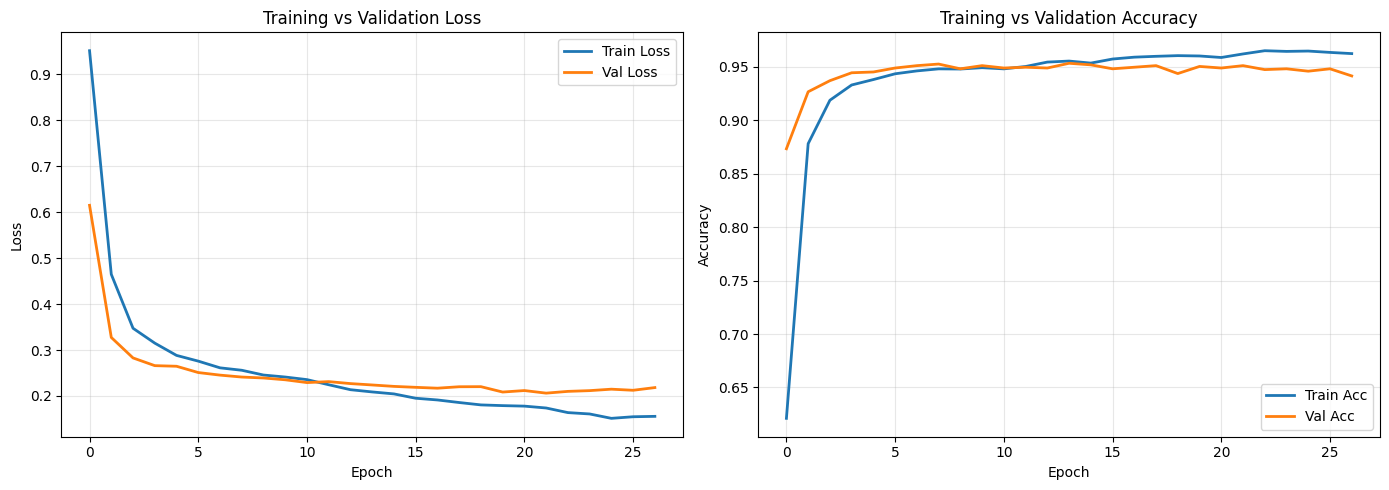

Status: WELL-FIT. Train and validation curves converge closely.


In [36]:

# Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5,   min_delta=0.001,restore_best_weights=True, verbose=0
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
)

# Train
history = model.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=0
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/training_curves_initial.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretation
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

if val_acc < train_acc - 0.05:
    print(f"Status: OVERFITTING detected. Validation accuracy lags training by >5%.")
elif train_acc < 0.6 and val_acc < 0.6:
    print(f"Status: UNDERFITTING suspected. Both curves are low.")
else:
    print(f"Status: WELL-FIT. Train and validation curves converge closely.")

In [37]:
def build_tunable_model(input_dim, config):
    l2_reg = config.get('l2_reg', 0.001)
    dropout_rate = config.get('dropout_rate', 0.3)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    model.add(layers.Dense(config['units_1'], activation='relu',
                          kernel_regularizer=regularizers.l2(l2_reg)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(config['units_2'], activation='relu',
                          kernel_regularizer=regularizers.l2(l2_reg)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))

    if config.get('units_3', 0) > 0:
        model.add(layers.Dense(config['units_3'], activation='relu',
                              kernel_regularizer=regularizers.l2(l2_reg)))

    model.add(layers.Dense(3, activation='softmax'))

    optimizer = keras.optimizers.Adam(learning_rate=config['lr'])
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

configs = [
    {'name': 'Baseline', 'units_1': 64, 'units_2': 32, 'units_3': 16,
     'lr': 0.001, 'dropout_rate': 0.3, 'l2_reg': 0.001, 'batch_size': 32},
    {'name': 'Wider', 'units_1': 128, 'units_2': 64, 'units_3': 32,
     'lr': 0.001, 'dropout_rate': 0.3, 'l2_reg': 0.001, 'batch_size': 32},
    {'name': 'Deeper', 'units_1': 64, 'units_2': 32, 'units_3': 16,
     'lr': 0.001, 'dropout_rate': 0.5, 'l2_reg': 0.01, 'batch_size': 32},
    {'name': 'Lower_LR', 'units_1': 64, 'units_2': 32, 'units_3': 16,
     'lr': 0.0001, 'dropout_rate': 0.3, 'l2_reg': 0.001, 'batch_size': 16},
    {'name': 'Large_Batch', 'units_1': 64, 'units_2': 32, 'units_3': 16,
     'lr': 0.001, 'dropout_rate': 0.2, 'l2_reg': 0.0001, 'batch_size': 64},
]

tuning_results = []

for config in configs:
    tf.keras.backend.clear_session()

    model_t = build_tunable_model(input_dim, config)

    hist = model_t.fit(
        X_train_proc, y_train,
        validation_data=(X_val_proc, y_val),
        epochs=50,
        batch_size=config['batch_size'],
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                  restore_best_weights=True, verbose=0)],
        class_weight=class_weight_dict,
        verbose=0
    )

    best_val_acc = max(hist.history['val_accuracy'])
    best_val_loss = min(hist.history['val_loss'])
    epochs_trained = len(hist.history['loss'])

    tuning_results.append({
        'Config': config['name'],
        'Units': f"{config['units_1']}-{config['units_2']}-{config['units_3']}",
        'LR': config['lr'],
        'Dropout': config['dropout_rate'],
        'L2': config['l2_reg'],
        'Batch': config['batch_size'],
        'Val_Acc': round(best_val_acc, 4),
        'Val_Loss': round(best_val_loss, 4),
        'Epochs': epochs_trained
    })

tuning_df = pd.DataFrame(tuning_results)

best_idx = tuning_df['Val_Acc'].idxmax()
best_config = configs[best_idx]

tf.keras.backend.clear_session()
best_model = build_tunable_model(input_dim, best_config)

best_history = best_model.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=100,
    batch_size=best_config['batch_size'],
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                              restore_best_weights=True, verbose=0)],
    class_weight=class_weight_dict,
    verbose=0
)

# PART D - STEP 1: FINAL EVALUATION


In [38]:
# Predict on test
y_pred_probs = best_model.predict(X_test_proc, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Overall accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)
macro_f1 = precision_recall_fscore_support(y_test, y_pred, average='macro')[2]
weighted_f1 = precision_recall_fscore_support(y_test, y_pred, average='weighted')[2]

metrics_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print(f"\nPer-class metrics:")
print(metrics_df.round(4).to_string(index=False))

print(f"\nMacro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")



Test Accuracy: 0.9578

Per-class metrics:
     Class  Precision  Recall  F1-Score  Support
    Glioma     0.9876  0.9789    0.9833      570
Meningioma     0.9343  0.9504    0.9423      464
 Pituitary     0.9393  0.9304    0.9348      316

Macro F1: 0.9535
Weighted F1: 0.9578


# PART D - STEP 2: CONFUSION MATRIX


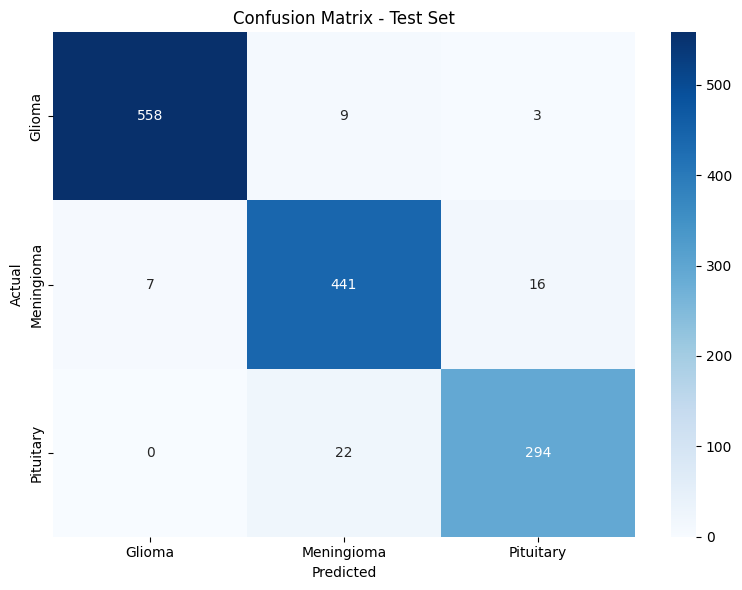


Most confused pair: Pituitary -> Meningioma (22 cases)


In [39]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Find most confused pair
# Off-diagonal elements
max_confusion = 0
confused_pair = None
for i in range(3):
    for j in range(3):
        if i != j and cm[i, j] > max_confusion:
            max_confusion = cm[i, j]
            confused_pair = (label_encoder.classes_[i], label_encoder.classes_[j])

print(f"\nMost confused pair: {confused_pair[0]} -> {confused_pair[1]} ({max_confusion} cases)")


# PART D - STEP 3: CONFIDENCE ANALYSIS


In [40]:

max_probs = np.max(y_pred_probs, axis=1)

# High confidence (top 2)
high_idx = np.argsort(max_probs)[-2:][::-1]
print(f"\nHIGH CONFIDENCE PREDICTIONS:")
for idx in high_idx:
    actual = label_encoder.inverse_transform([y_test[idx]])[0]
    predicted = label_encoder.inverse_transform([y_pred[idx]])[0]
    probs = dict(zip(label_encoder.classes_, y_pred_probs[idx].round(4)))
    print(f"  Test index {idx}: Actual={actual}, Predicted={predicted}")
    print(f"    Probabilities: {probs}")
    print(f"    Confidence: {max_probs[idx]:.4f}")

# Low confidence (bottom 2)
low_idx = np.argsort(max_probs)[:2]
print(f"\nLOW CONFIDENCE PREDICTIONS:")
for idx in low_idx:
    actual = label_encoder.inverse_transform([y_test[idx]])[0]
    predicted = label_encoder.inverse_transform([y_pred[idx]])[0]
    probs = dict(zip(label_encoder.classes_, y_pred_probs[idx].round(4)))
    print(f"  Test index {idx}: Actual={actual}, Predicted={predicted}")
    print(f"    Probabilities: {probs}")
    print(f"    Confidence: {max_probs[idx]:.4f}")




HIGH CONFIDENCE PREDICTIONS:
  Test index 846: Actual=Glioma, Predicted=Glioma
    Probabilities: {'Glioma': np.float32(0.9996), 'Meningioma': np.float32(0.0003), 'Pituitary': np.float32(1e-04)}
    Confidence: 0.9996
  Test index 723: Actual=Glioma, Predicted=Glioma
    Probabilities: {'Glioma': np.float32(0.9995), 'Meningioma': np.float32(0.0003), 'Pituitary': np.float32(1e-04)}
    Confidence: 0.9995

LOW CONFIDENCE PREDICTIONS:
  Test index 975: Actual=Meningioma, Predicted=Pituitary
    Probabilities: {'Glioma': np.float32(0.1904), 'Meningioma': np.float32(0.3954), 'Pituitary': np.float32(0.4141)}
    Confidence: 0.4141
  Test index 156: Actual=Glioma, Predicted=Meningioma
    Probabilities: {'Glioma': np.float32(0.3118), 'Meningioma': np.float32(0.4702), 'Pituitary': np.float32(0.2179)}
    Confidence: 0.4702


# PART E - STEP 1: BASELINE COMPARISON


In [41]:

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, class_weight='balanced')
rf.fit(X_train_proc, y_train)
rf_pred = rf.predict(X_test_proc)
rf_acc = accuracy_score(y_test, rf_pred)
rf_macro_f1 = precision_recall_fscore_support(y_test, rf_pred, average='macro')[2]

# Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
lr.fit(X_train_proc, y_train)
lr_pred = lr.predict(X_test_proc)
lr_acc = accuracy_score(y_test, lr_pred)
lr_macro_f1 = precision_recall_fscore_support(y_test, lr_pred, average='macro')[2]

comparison = pd.DataFrame({
    'Model': ['Neural Network', 'Random Forest', 'Logistic Regression'],
    'Test Accuracy': [test_acc, rf_acc, lr_acc],
    'Macro F1': [macro_f1, rf_macro_f1, lr_macro_f1]
})
print(f"\nBaseline Comparison:")
print(comparison.round(4).to_string(index=False))



Baseline Comparison:
              Model  Test Accuracy  Macro F1
     Neural Network         0.9578    0.9535
      Random Forest         0.9570    0.9536
Logistic Regression         0.9585    0.9543


# PART E - STEP 2: FEATURE IMPORTANCE


In [ ]:
# Use Random Forest for permutation importance (model-agnostic but needs a fitted model)
rf_for_perm = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
rf_for_perm.fit(X_train_proc, y_train)

perm = permutation_importance(rf_for_perm, X_test_proc, y_test,
                               n_repeats=10, random_state=RANDOM_SEED, scoring='f1_macro')

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 most important features:")
print(importance_df.head(10).round(4).to_string(index=False))

print(f"\nBottom 5 least important features:")
print(importance_df.tail(5).round(4).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances (Permutation)')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Two unimportant features
unimportant = importance_df.tail(2)['Feature'].tolist()
print(f"\nTwo largely unimportant features: {unimportant}")


# SAVE FINAL MODEL AND ARTIFACTS


In [ ]:

model.save('models/final_model.keras')
best_model.save('models/studentID_model.h5')
print(f"Model saved: models/studentID_model.h5")

# Save config for reference
config_save = {
    'random_seed': RANDOM_SEED,
    'input_dim': input_dim,
    'best_config': best_config,
    'numeric_cols': NUMERIC_COLS,
    'categorical_cols': CATEGORICAL_COLS,
    'ordinal_cols': ORDINAL_COLS,
    'ordinal_orders': {'alcohol_consumption': ALCOHOL_ORDER,
                       'contrast_enhancement': CONTRAST_ORDER}
}
with open('models/config.json', 'w') as f:
    json.dump(config_save, f, indent=2)
print(f"Config saved: models/config.json")

print(f"\nAll artifacts saved. Ready for predict.py")

Model saved: models/studentID_model.h5
Config saved: models/config.json

All artifacts saved. Ready for predict.py


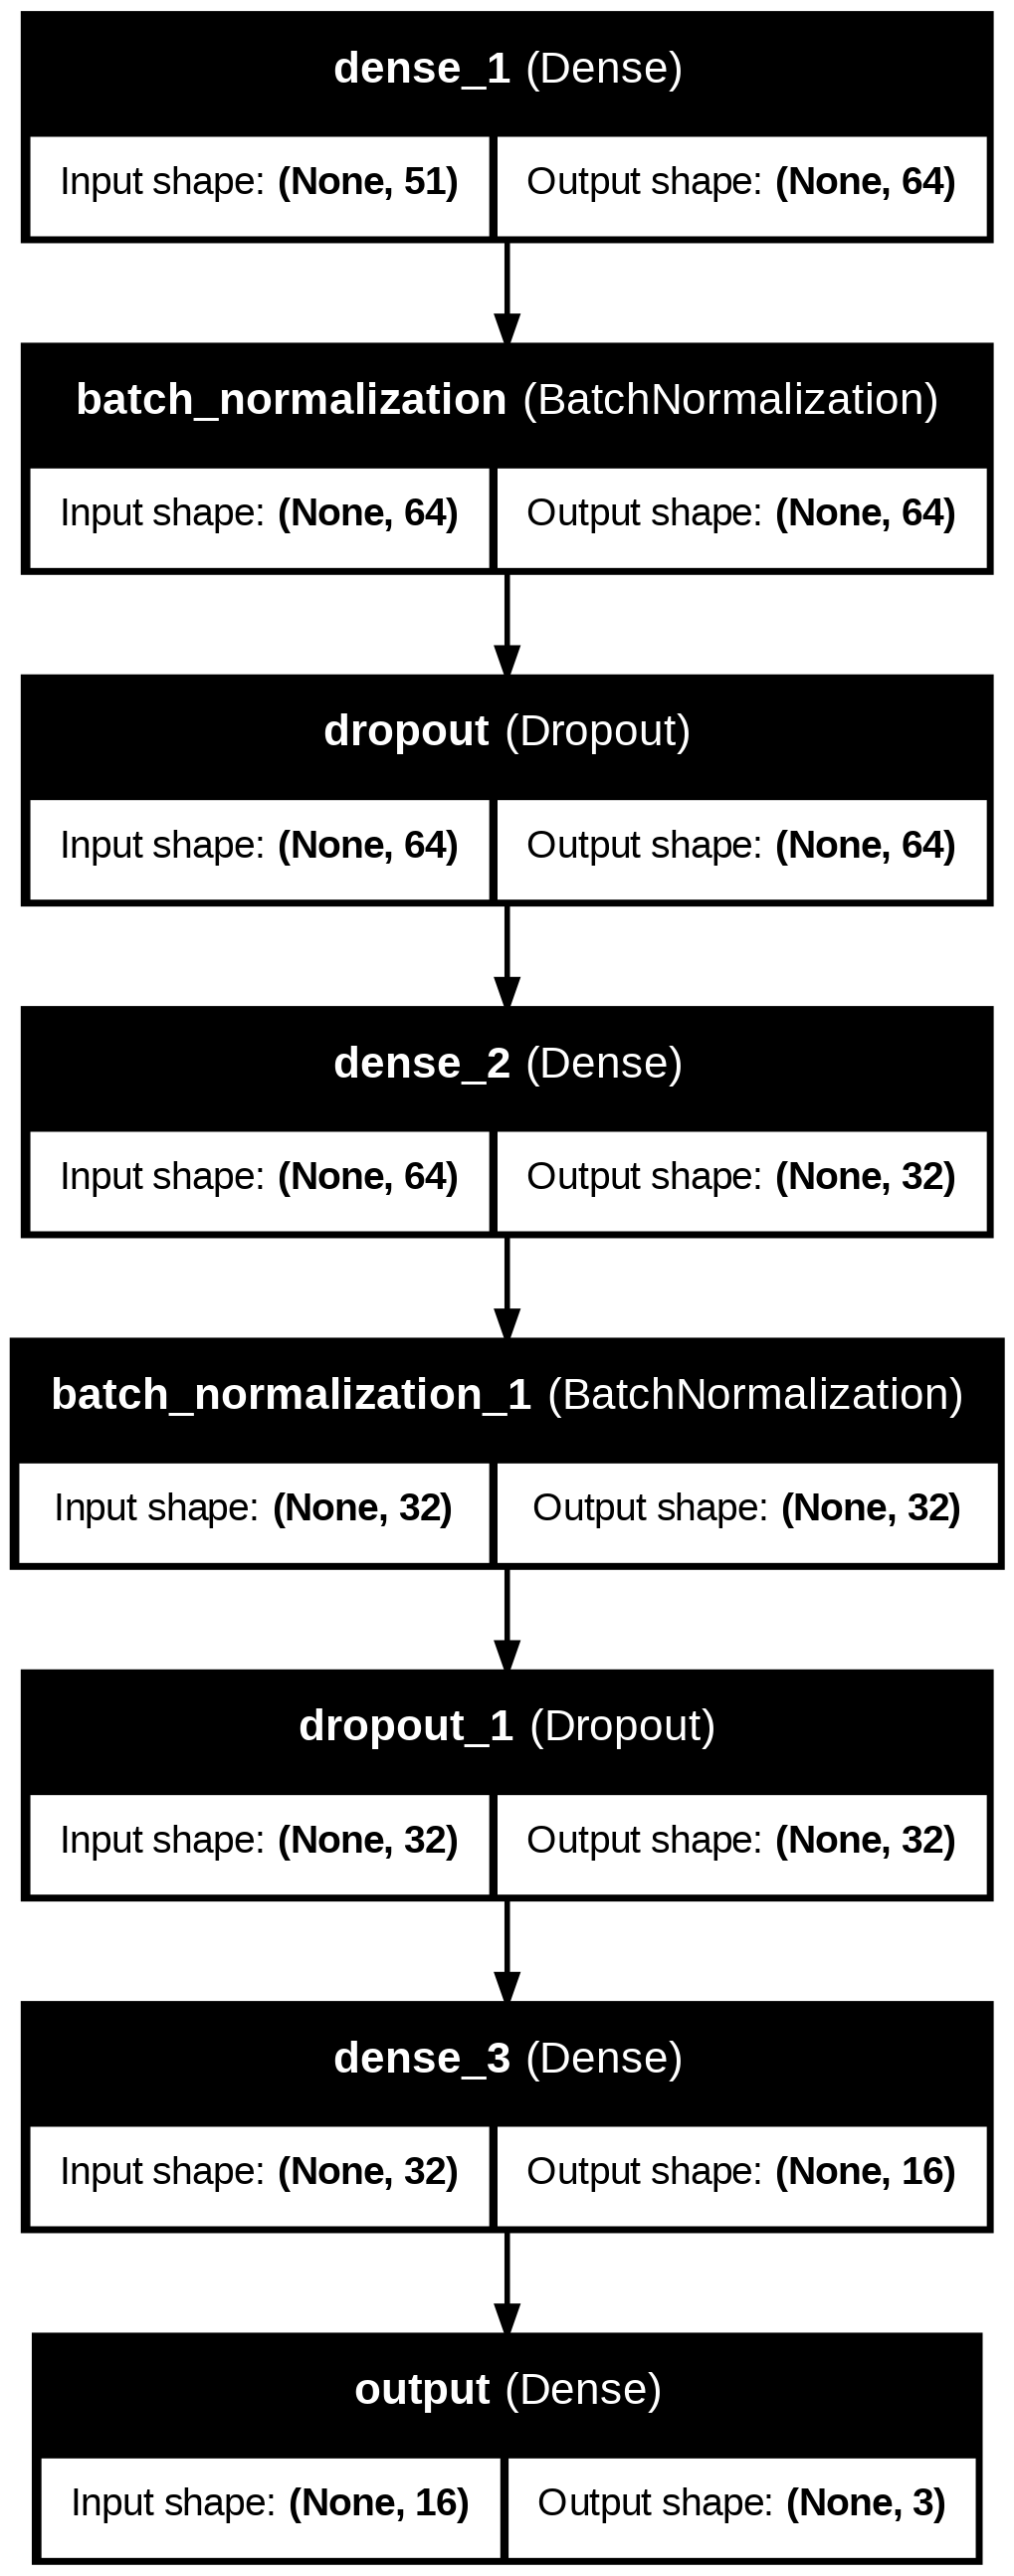

In [ ]:
keras.utils.plot_model(model, to_file='figures/model_architecture.png',
                       show_shapes=True, show_layer_names=True)

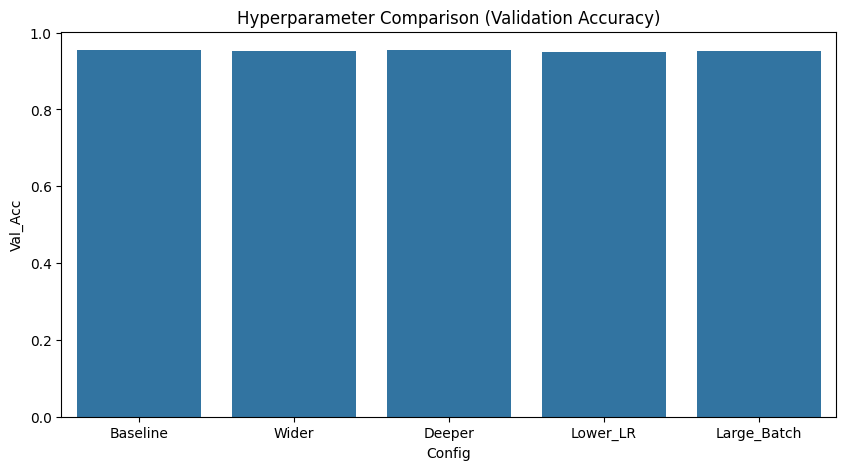

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=tuning_df, x='Config', y='Val_Acc')
plt.title('Hyperparameter Comparison (Validation Accuracy)')
plt.savefig('figures/hyperparameter_comparison.png')

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

      Glioma       0.99      0.97      0.98       570
  Meningioma       0.92      0.95      0.94       464
   Pituitary       0.93      0.92      0.93       316

    accuracy                           0.95      1350
   macro avg       0.95      0.95      0.95      1350
weighted avg       0.95      0.95      0.95      1350

